In [178]:
# author: Suhas Vittal

import importlib
from plotting import *

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

WORKLOAD_ORDER = [
    ['cam4', 'roms', 'omnetpp', 'bwaves', 'fotonik3d', 'wrf', 'lbm'],
    ['triangle', 'cf', 'pagerankdelta', 'mis', 'bc', 'bellmanford', 'pagerank', 'radii'],
    ['scale', 'copy', 'triad', 'add'],
    ['whiskey', 'charlie', 'merced', 'delta'],
    ['mix0', 'mix1', 'mix2', 'mix3', 'mix4', 'mix5']
]

ALL_WORKLOADS = []
for suite in WORKLOAD_ORDER:
    ALL_WORKLOADS.extend(suite)

ALL_WORKLOADS_PLUS_GMEAN = ALL_WORKLOADS.copy()
ALL_WORKLOADS_PLUS_GMEAN.append('gmean')

ALL_WORKLOADS_PLUS_MEAN = ALL_WORKLOADS.copy()
ALL_WORKLOADS_PLUS_MEAN.append('mean')

MIX_REORDER_MAP = {
    'mix2': 'mix0',
    'mix5': 'mix1',
    'mix0': 'mix2',
    'mix3': 'mix3',
    'mix1': 'mix4',
    'mix4': 'mix5'
}

def REORDER(data):
    _data = {}
    for (w,x) in data.items():
        if w in MIX_REORDER_MAP:
            _data[MIX_REORDER_MAP[w]] = x
        else:
            _data[w] = x
    return _data


C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898121' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

VERSION = 5

In [179]:
def plot_speedup(ax, baseline_data, policy_data: list, legend: list, colors: list, legend_ncols=1):
    ax.set_ylabel('Speedup (%)', fontsize=12)

    if type(baseline_data) is not list:
        baseline_data = [baseline_data for _ in policy_data]
    
    width = 1.0 / (len(policy_data)+1)
    offset = 0

    X = []
    _x = 0
    for suite in WORKLOAD_ORDER:
        X.extend(list(range(_x, _x+len(suite))))
        _x += len(suite)+1
    X.append(_x)
    X = np.array(X)
    
    for (i, pd) in enumerate(policy_data):
        bd = baseline_data[i]
        label = legend[i]
        Y = []
        for suite in WORKLOAD_ORDER:
            for w in suite:
                baseline_ipc = bd[w]['IPC']
                policy_ipc = pd[w]['IPC']
                Y.append(policy_ipc/baseline_ipc)
            # plot bar:
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        Y = (Y-1)*100
        ax.bar(X+offset, Y, width, color=colors[i], label=legend[i], edgecolor='k', zorder=3)
        offset += width

    # set x labels to workloads
    workload_x_ticks = X + (len(legend)-1)/2 * width
    ax.set_xticks(workload_x_ticks, ALL_WORKLOADS_PLUS_GMEAN, rotation=30, ha='right', fontsize=10)
    ax.grid(visible=True, axis='y', zorder=0)
    ax.legend(fontsize=10, ncols=legend_ncols, loc='upper right')

In [180]:
BASELINE = REORDER(read_csv_data('../data/baseline.csv'))
BARD = REORDER(read_csv_data('../data/bard.csv'))
BARD_E = REORDER(read_csv_data('../data/bard_e.csv'))
BARD_C = REORDER(read_csv_data('../data/bard_c.csv'))
EAGER = REORDER(read_csv_data('../data/eager.csv'))
VWQ = REORDER(read_csv_data('../data/vwq.csv'))

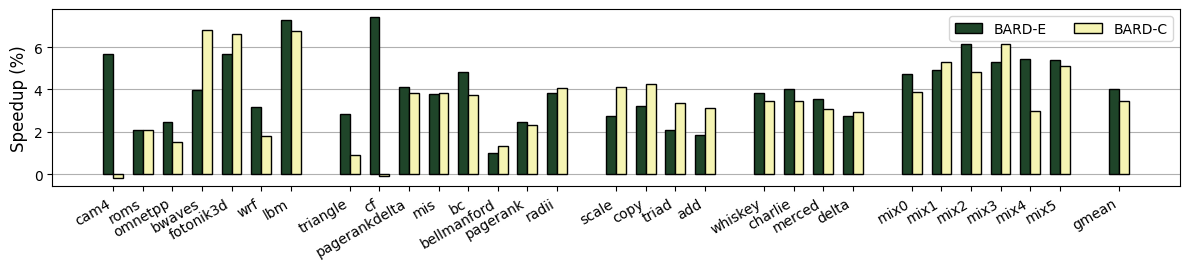

In [181]:
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 2.8)

plot_speedup(ax, BASELINE, [BARD_E, BARD_C], ['BARD-E', 'BARD-C'], colors=[C3,C1], legend_ncols=2)

plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_bard_e_and_c_only.pdf', bbox_inches='tight')

64.69996076026042
4.842080694875999
30.45795854486358


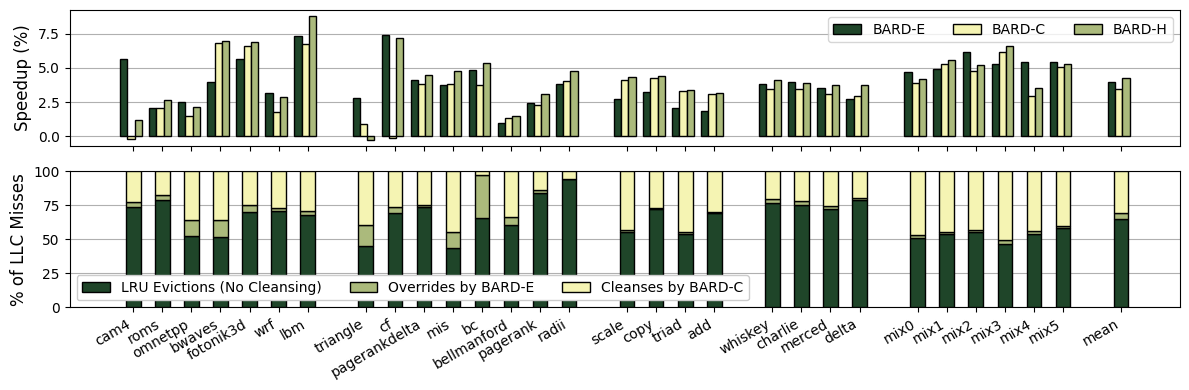

In [182]:
fig, (ax1,ax2) = plt.subplots(2,1,sharex=True)
fig.set_size_inches(12.0, 4.0)

plot_speedup(ax1,
            BASELINE,
            [BARD_E, BARD_C, BARD], ['BARD-E', 'BARD-C', 'BARD-H'],
            colors=[C3,C1,C4],
            legend_ncols=3)

# second axis will show breakdown of bard decisions:
ax2.set_ylabel('% of LLC Misses', fontsize=12)
total_evictions = get_stat_for_workloads(BARD, 'Total Evictions')
bard_e_evictions = get_stat_for_workloads(BARD, 'BARD E Evictions')
bard_c_evictions = get_stat_for_workloads(BARD, 'BARD C Cleanses')
bard_unaff_evictions = {w : (total_evictions[w] - bard_e_evictions[w] - bard_c_evictions[w]) for w in total_evictions}

# create x axis ticks:
X = []
_x = 0
for suite in WORKLOAD_ORDER:
    X.extend(list(range(_x, _x+len(suite))))
    _x += len(suite)+1
X.append(_x)
X = np.array(X)

def plot_stacked_bar(data_map: dict, y_base: list, label: str, color):
    Y = []
    for (w, y) in data_map.items():
        Y.append(y / total_evictions[w])
    Y.append( np.mean(Y) )
    Y = np.array(Y)*100

    print(Y[-1])
    
    ax2.bar(X+0.33, Y, 0.5, bottom=Y_BASE, label=label, color=color, edgecolor='k', zorder=3)
    return y_base + Y

Y_BASE = np.zeros(len(X))
Y_BASE = plot_stacked_bar(bard_unaff_evictions, Y_BASE, 'LRU Evictions (No Cleansing)', C3)
Y_BASE = plot_stacked_bar(bard_e_evictions, Y_BASE, 'Overrides by BARD-E', C4)
Y_BASE = plot_stacked_bar(bard_c_evictions, Y_BASE,  'Cleanses by BARD-C', C1)

# format ax2:
ax2.set_ylim([0,100])
ax2.set_xticks(X+0.33, ALL_WORKLOADS_PLUS_MEAN, fontsize=10, ha='right', rotation=30)
ax2.legend(fontsize=10, framealpha=1, loc='lower left', ncols=3)
ax2.grid(visible=True, axis='y', zorder=0)

plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_bard_speedup_all_versions.pdf', bbox_inches='tight')

0.9893485678543863 0.19955252432178155 23.28057764186528 0.28097637842708945 21.98331455175785


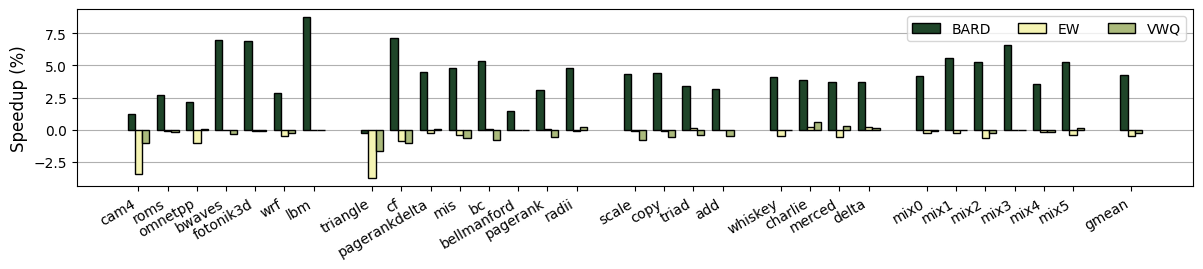

In [183]:
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 2.8)

plot_speedup(ax,
             BASELINE,
             [BARD, EAGER, VWQ], ['BARD', 'EW', 'VWQ'],
             colors=[C3,C1,C4],
            legend_ncols=3)

plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_bard_speedup_with_vwq_and_eager.pdf', bbox_inches='tight')

# print some example stats for VWQ slowdown:
def print_vwq_example(w):
    baseline_perf, baseline_rbhr, baseline_blp = BASELINE[w]['IPC'], BASELINE[w]['Write RBHR'], BASELINE[w]['Write BLP']
    vwq_perf, vwq_rbhr, vwq_blp = VWQ[w]['IPC'], VWQ[w]['Write RBHR'], VWQ[w]['Write BLP']

    slowdown = vwq_perf/baseline_perf
    print(slowdown, baseline_rbhr, baseline_blp, vwq_rbhr, vwq_blp)
print_vwq_example('cf')

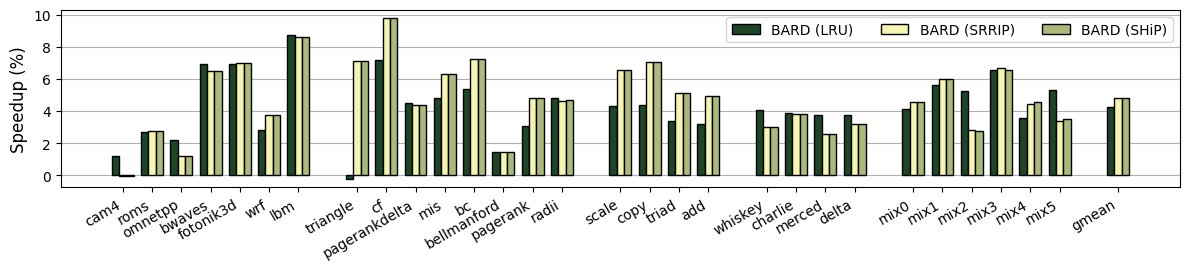

In [184]:
BASELINE_SRRIP = REORDER(read_csv_data('../data/baseline_srrip.csv'))
BASELINE_SHIP = REORDER(read_csv_data('../data/baseline_ship.csv'))
BARD_SRRIP = REORDER(read_csv_data('../data/bard_srrip.csv'))
BARD_SHIP = REORDER(read_csv_data('../data/bard_ship.csv'))

fig, ax = plt.subplots()
fig.set_size_inches(12.0, 2.8)

plot_speedup(ax,
             [BASELINE, BASELINE_SRRIP, BASELINE_SHIP],
             [BARD, BARD_SRRIP, BARD_SHIP], ['BARD (LRU)', 'BARD (SRRIP)', 'BARD (SHiP)'],
            colors=[C3,C1,C4],
            legend_ncols=3)

plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_bard_speedup_different_repl.pdf', bbox_inches='tight')

In [185]:
def plot_stat(ax, y_axis_data: list[dict], legend: list, ylabel: str, colors: list, legend_ncols=1, is_percentage=False, plot_mean=None):
    ax.set_ylabel(ylabel, fontsize=12)

    width = 1.0 / (len(legend)+1)
    offset = 0

    WORKLOAD_LABELS = ALL_WORKLOADS.copy()
    if plot_mean:
        WORKLOAD_LABELS.append('mean')

    X = []
    _x = 0
    for suite in WORKLOAD_ORDER:
        X.extend(list(range(_x, _x+len(suite))))
        _x += len(suite)+1
    if plot_mean:
        X.append(_x)
    X = np.array(X)
    
    for (i, pd) in enumerate(y_axis_data):
        label = legend[i]
        Y = []
        for suite in WORKLOAD_ORDER:
            for w in suite:
                d = pd[w]
                Y.append(d)
        # plot bar:
        if plot_mean == 'hmean':
            Y.append( len(Y) / sum(1.0/y for y in Y) )
        elif plot_mean == 'amean':
            Y.append( np.mean(Y) )
        Y = np.array(Y)
        if is_percentage:
            Y = Y*100
        ax.bar(X+offset, Y, width, color=colors[i], label=legend[i], edgecolor='k', zorder=3)
        offset += width

    # set x labels to workloads
    workload_x_ticks = X + (len(legend)-1)/2 * width
    ax.set_xticks(workload_x_ticks, WORKLOAD_LABELS, rotation=30, ha='right', fontsize=10)
    ax.grid(visible=True, axis='y', zorder=0)
    if len(legend) > 1:
        ax.legend(fontsize=10, ncols=legend_ncols, loc='upper right')

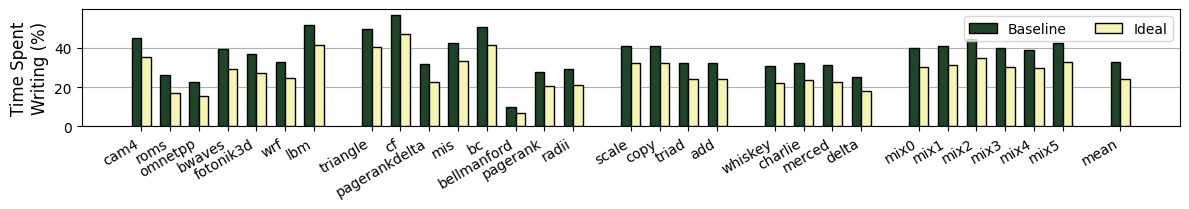

In [186]:
fig, ax = plt.subplots()
fig.set_size_inches(12.0,2.2)

write_mode_time = get_stat_for_workloads(BASELINE, 'Write Mode Fraction')
ideal_write_mode_time = get_stat_for_workloads(BASELINE, 'Ideal Write Mode Fraction')

plot_stat(ax, 
          [write_mode_time, ideal_write_mode_time], ['Baseline', 'Ideal'],
          'Time Spent\nWriting (%)',
          [C3,C1],
          legend_ncols=2,
          is_percentage=True, plot_mean='hmean')
plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_write_mode_time_baseline_only.pdf', bbox_inches='tight')

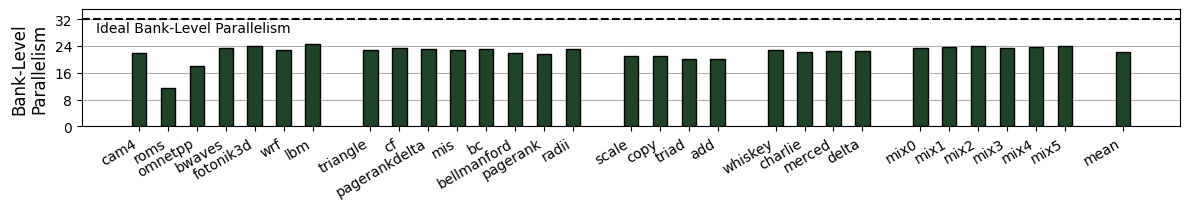

In [187]:
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 2.2)

blp = get_stat_for_workloads(BASELINE, 'Write BLP')

plot_stat(ax,
          [blp], [''],
          'Bank-Level\nParallelism',
          [C3],
          plot_mean='amean')
ax.set_yticks([0,8,16,24,32])
ax.set_ylim([0,35])
ax.axhline(y=32, linestyle='--', color='k')
ax.text(-1.5, 28, 'Ideal Bank-Level Parallelism', fontsize=10)

plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_bank_parallelism_baseline_only.pdf', bbox_inches='tight')

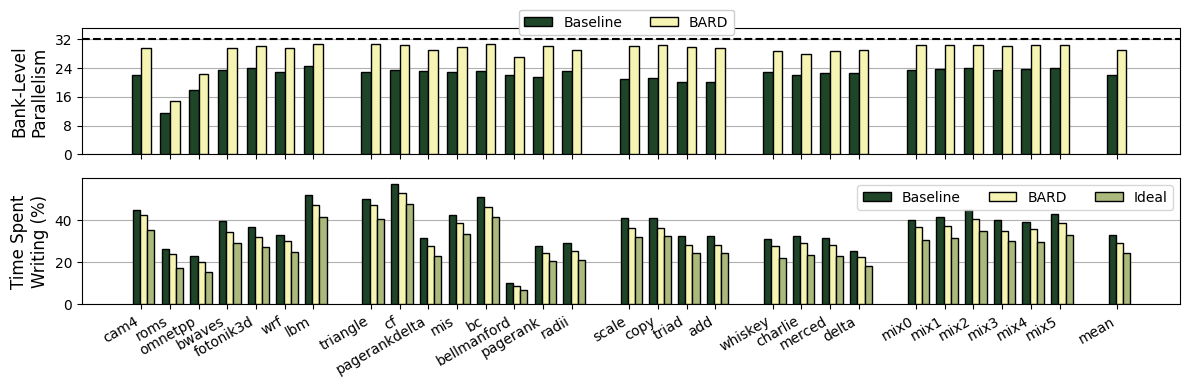

In [188]:
fig, (ax1,ax2) = plt.subplots(2,1,sharex=True)
fig.set_size_inches(12.0, 4.0)

baseline_wm = get_stat_for_workloads(BASELINE, 'Write Mode Fraction')
bard_wm = get_stat_for_workloads(BARD, 'Write Mode Fraction')
ideal_wm = get_stat_for_workloads(BASELINE, 'Ideal Write Mode Fraction')

baseline_blp = get_stat_for_workloads(BASELINE, 'Write BLP')
bard_blp = get_stat_for_workloads(BARD, 'Write BLP')

plot_stat(ax2, [baseline_wm,bard_wm,ideal_wm], ['Baseline', 'BARD', 'Ideal'], 'Time Spent\nWriting (%)', [C3,C1,C4], legend_ncols=3, is_percentage=True, plot_mean='hmean')
plot_stat(ax1, [baseline_blp,bard_blp], ['Baseline', 'BARD'], 'Bank-Level\nParallelism', [C3,C1], legend_ncols=2, plot_mean='amean')

ax1.set_yticks([0,8,16,24,32])
ax1.set_ylim([0,35])
ax1.axhline(y=32, linestyle='--', color='k')
ax1.legend(fontsize=10, ncols=2, bbox_to_anchor=(0.6,1.2), framealpha=1)
#ax1.text(-1.5, 28, 'Ideal Bank-Level Parallelism', fontsize=10)

plt.tight_layout()
plt.savefig(f'bard_plots/v{VERSION}_final_blp_and_write_mode_time.pdf', bbox_inches='tight')

In [ ]:
power = [362.1, 384.0, 358.1]
energy = [28.75, 29.03, 28.45]
edp = [3.14, 3.00, 3.10]

fig,ax = plt.subplots()

ax.